# Filter initial dataset for plots




For the downstream analysis of MAF, rescaled effect size and variant effects we need to filter the `LeadVariantEffect` dataset to:

1. Limit the dataset to `gwas, cis-pqtl and eqlt` datasets.
2. Split the GWAS studies into two types:
   - measurements (continuous traits)
   - diseases (binary traits bound to therapeutic areas)
3. Apply the `replicated` mask to the GWAS-measurements, GWAS-diseases and molecular QTL datasets.
4. Apply the `qualified` mask to the GWAS-measurements, GWAS-diseases.
5. Apply Posterior Inclusion Probability (PIP) filter to all lead variants, keeping only those with PIP >= 0.5.

After the filtering applied check how many variants are left in the dataset and compute statistics on rescaled effect size & MAF.

5. Ensure there is no lead variants with MAF == 0.0 or MAF is NULL
6. Ensure there is no lead variants with absolute value of rescaled effect size <= 3 and is not empty

The resulting dataset should be split into two datasets:

- lead variant effects with MAF >= 0.01 (qualified_lead_variant_effect_maf_filtered)
- lead variant effects with all variants (qualified_lead_variant_effect)


## Data Loading

The data required for the analysis is loaded from the

- `lead variant effect` dataset
- `qualified gwas measurements` dataset
- `qualified gwas diseases` dataset
- `replicated molecular qtls` dataset
- `replicated gwas` dataset


### Data file paths


In [1]:
qualifying_gwas_disease_credible_set_path = "../../../data/intermediate_files/qualifying_credible_sets"
qualifying_gwas_measurements_credible_set_path = "../../../data/intermediate_files/qualifying_measurement_credible_sets"
lead_variant_effect_dataset_path = "../../../data/intermediate_files/lead_variant_effect"

replicated_molqtls_path = "../../../data/intermediate_files/list_of_molqtls_replicated_CSs.parquet"
replicated_gwas_path = "../../../data/intermediate_files/list_of_gwas_replicated_CSs.parquet"
replicated_credible_sets_path = "../../data/replicated_credible_sets"


# Output paths
qualified_lve_path = "../../../data/intermediate_files/qualified_lead_variant_effect"
qualified_lve_maf_filtered_path = "../../../data/intermediate_files/qualified_lead_variant_effect_maf_filtered"


### Data reading


In [2]:
import numpy as np
import pandas as pd
import plotnine as p9
from gentropy.common.session import Session
from pyspark.sql import DataFrame
from pyspark.sql import functions as f

from manuscript_methods import OpenTargetsTheme, group_statistics
from manuscript_methods.datasets import LeadVariantEffect
from manuscript_methods.locus_statistics import LocusStatistics
from manuscript_methods.study_statistics import StudyStatistics, StudyType


Loading BokehJS ...

/home/mindos/Projects/OpenTargets/gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [3]:
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})
full_lve = LeadVariantEffect.from_parquet(session=session, path=lead_variant_effect_dataset_path)
qualified_gwas_measurements_lve = LeadVariantEffect.from_parquet(
    session=session, path=qualifying_gwas_measurements_credible_set_path
)
qualified_gwas_disease_lve = LeadVariantEffect.from_parquet(
    session=session, path=qualifying_gwas_disease_credible_set_path
)
replicated_molqtls = session.spark.read.parquet(replicated_molqtls_path)
replicated_gwas = session.spark.read.parquet(replicated_gwas_path)


26/01/12 11:52:17 WARN Utils: Your hostname, mindos resolves to a loopback address: 127.0.1.1; using 192.168.0.100 instead (on interface eno1)
26/01/12 11:52:17 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/12 11:52:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Analysis steps

1. Filter full lve dataset to keep only `cis-pqtl` and `eqtl` signals.
2. Union with the `qualified gwas measurements` and `qualified gwas diseases` lve datasets
3. Limit the signals to the replicated ones (inner join with replicated gwas and replicated molqtls)
4. Remove lead variants with MAF == 0.0 and empty MAF 
5. Remove lead variants where absolute value of rescaled effect size <= 3
6. Filter by PIP >= 0.5
7. Save the dataset
8. MAF filter >= 0.01
9. Save the filtered datasets


In [4]:
PIP_THRESHOLD = 0.5
RESCALED_BETA_ABS_THRESHOLD = 3
MAF_THRESHOLD = None
MAF_THRESHOLD_FILTERED = 0.01


#### Filter based on cis-pqtl and eqtl signals

In [5]:
print("Filtering to molecular QTLs (cis-pQTLs and eQTLs) and removing trans-QTLs")
print(f"Before filtering qtls: {full_lve.df.count():,}")
molqtl_lve = LeadVariantEffect(
    full_lve.df.filter(
        StudyStatistics().study_type.isin(
            StudyType.CIS_PQTL,
            StudyType.EQTL,
        )
    ).filter(~f.col("isTransQtl"))
)
print(f"After filtering qtls: {molqtl_lve.df.count():,}")


Filtering to molecular QTLs (cis-pQTLs and eQTLs) and removing trans-QTLs
Before filtering qtls: 2,833,758
After filtering qtls: 1,365,531


#### Filter based on qualified gwas measurements and diseases datasets

In [6]:
print("Filtering based on qualified gwas measurements and diseases datasets")
print(f"Before union - qualified measurements: {qualified_gwas_measurements_lve.df.count():,}")
print(f"Before union - qualified disease: {qualified_gwas_disease_lve.df.count():,}")
print(f"Before union - molqtl: {molqtl_lve.df.count():,}")

study_stats = StudyStatistics()

# Adjust the study types
qualified_gwas_measurements_lve = LeadVariantEffect(
    qualified_gwas_measurements_lve.df.withColumn(
        study_stats.name, study_stats.transform_study_type(StudyType.GWAS_MEASUREMENT).col
    )
)
qualified_gwas_disease_lve = LeadVariantEffect(
    qualified_gwas_disease_lve.df.withColumn(
        study_stats.name, study_stats.transform_study_type(StudyType.GWAS_DISEASE).col
    )
)


qualified_lve = LeadVariantEffect(
    molqtl_lve.df.unionByName(qualified_gwas_measurements_lve.df).unionByName(qualified_gwas_disease_lve.df)
)
print(f"After union: {qualified_lve.df.count():,}")


Filtering based on qualified gwas measurements and diseases datasets
Before union - qualified measurements: 450,357
Before union - qualified disease: 70,618
Before union - molqtl: 1,365,531
After union: 1,886,506


#### Filter based on replicated credible sets

In [7]:
# Filter based on replicated credible sets
print(f"Before filter - qualified credible sets: {qualified_lve.df.count():,}")
print(f"Before filter - replicated GWAS measurement and disease credible sets: {replicated_gwas.count():,}")
print(f"Before filter - replicated molQTL credible sets: {replicated_molqtls.count():,}")
replicated_cs_df = replicated_gwas.unionByName(replicated_molqtls).cache()
cs_count = replicated_cs_df.count()
print(f"Before filter - replicated credible sets: {cs_count:,}")
replicated_qualified_lve = qualified_lve.filter_by_study_locus_id(replicated_cs_df)
print(f"After filter - qualified replicated credible sets: {replicated_qualified_lve.df.count():,}")


Before filter - qualified credible sets: 1,886,506
Before filter - replicated GWAS measurement and disease credible sets: 263,705
Before filter - replicated molQTL credible sets: 1,461,445
Before filter - replicated credible sets: 1,725,150


StudyLocus dimension: 1725150, unique studyLocusId: 1725150


Initial rows: 1886506
Filtered 749416 rows based on the StudyLocus.
Remaining rows: 1137090
After filter - qualified replicated credible sets: 1,137,090


#### Filter MAF and abs effect size outliers

In [8]:
print("Filtering lead variant effects based on MAF and effect size outliers")
print(f"Before filter - qualified replicated credible sets: {replicated_qualified_lve.df.count():,}")
lve_filtered = replicated_qualified_lve.maf_filter(
    remove_null=True, remove_zero=True, threshold=MAF_THRESHOLD
).effect_size_filter(effect_size_threshold=RESCALED_BETA_ABS_THRESHOLD)
print(f"After filter - qualified replicated credible sets: {lve_filtered.df.count():,}")


Filtering lead variant effects based on MAF and effect size outliers
Before filter - qualified replicated credible sets: 1,137,090


After filter - qualified replicated credible sets: 1,117,120


#### Filter based on PIP threshold

Starting pip thresholding
Thresholds to evaluate: [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


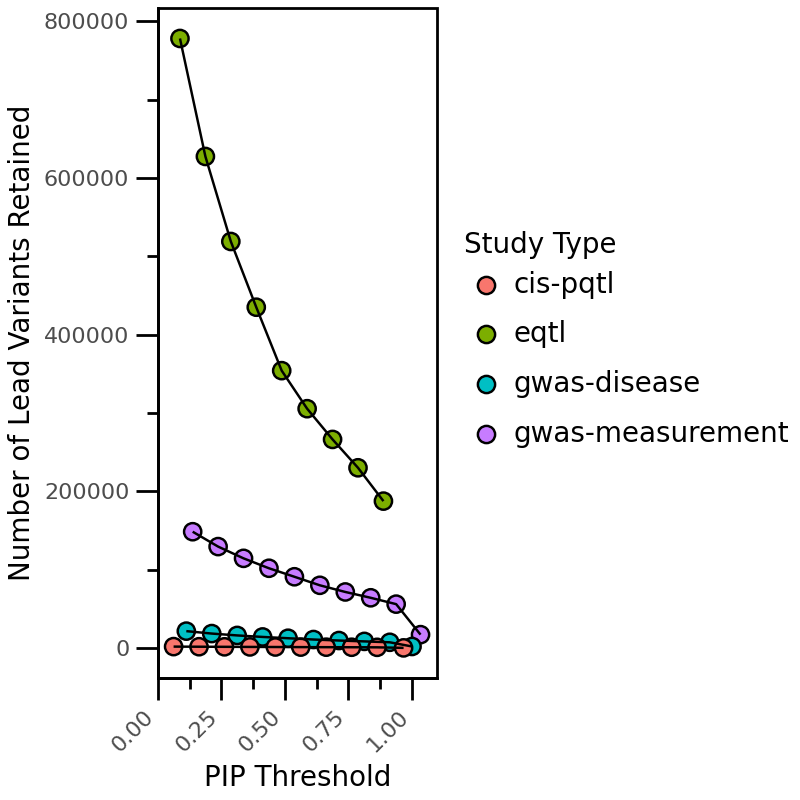

In [9]:
def pip_thresholding(df: DataFrame, thresholds: np.ndarray) -> pd.DataFrame:
    """Estimate the best PIP threshold for filtering lead variant effects."""
    print("Starting pip thresholding")
    print(f"Thresholds to evaluate: {thresholds}")
    locus_stats = LocusStatistics()

    total_counts = []

    for threshold in thresholds:
        group_cnts = (
            df.filter(locus_stats.col.getField("leadVariantPIP") >= threshold)
            .groupBy("studyStatistics.studyType")
            .agg(f.count("*").alias("nLeadVariants"))
            .withColumn("PIP_Threshold", f.lit(threshold))
        ).toPandas()

        total_counts.append(group_cnts)

    return pd.concat(total_counts, ignore_index=True)


### Choose PIP threshold
pip_thresholds = np.arange(0.1, 1.01, 0.1)
counts = pip_thresholding(lve_filtered.df, pip_thresholds)
# plot counts

(
    p9.ggplot(data=counts, mapping=p9.aes(x="PIP_Threshold", y="nLeadVariants", fill="studyType"))
    + p9.geom_point(position=p9.position_dodge(width=0.1), size=3)
    + p9.geom_line(p9.aes(group="studyType"), position=p9.position_dodge(width=0.1))
    + OpenTargetsTheme().categorical_theme()
    + p9.theme(
        figure_size=(4, 4),
        legend_position="right",
        axis_text_y=p9.element_text(size=8),
        axis_title_x=p9.element_text(size=10),
        axis_title_y=p9.element_text(size=10),
        axis_text_x=p9.element_text(size=8),
        title=p9.element_text(size=10),
    )
    + p9.labs(
        title="",
        x="PIP Threshold",
        y="Number of Lead Variants Retained",
        fill="Study Type",
    )
)


In [10]:
print("Filtering lead variant effects based on PIP outliers")
locus_stats = LocusStatistics()
print(f"Before filter - qualified replicated credible sets: {lve_filtered.df.count():,}")
lve_final = lve_filtered.filter(locus_stats.col.getField("leadVariantPIP") >= PIP_THRESHOLD)
print(f"After filter - qualified replicated credible sets: {lve_final.df.count():,}")
lve_filtered_maf = lve_final.maf_filter(threshold=MAF_THRESHOLD_FILTERED)
print(f"After MAF filter - qualified replicated credible sets: {lve_filtered_maf.df.count():,}")


Filtering lead variant effects based on PIP outliers


Before filter - qualified replicated credible sets: 1,117,120


After filter - qualified replicated credible sets: 459,516


After MAF filter - qualified replicated credible sets: 448,966


#### Save the dataset

In [11]:
lve_final.df.write.mode("overwrite").parquet(qualified_lve_path)
lve_filtered_maf.df.write.mode("overwrite").parquet(qualified_lve_maf_filtered_path)


## Sanity check

Post filtering sanity checks to ensure the filtering steps were successful.


### Check the number of rare variants 

In [12]:
# Apply MAF filter to 0.01
print(f"Before MAF filtering: {lve_final.df.count():,}")
print(f"After MAF filtering: {lve_filtered_maf.df.count():,}")


Before MAF filtering: 459,516


After MAF filtering: 448,966


### Check the number of studyTypes after all filtering


In [13]:
print("Final lead variant effect statistics:")
group_statistics(lve_final.df.select("studyStatistics.studyType"), [f.col("studyType")]).show()


Final lead variant effect statistics:


+----------------+------+-----+-------------------+
|       studyType| count|    %|         percentage|
+----------------+------+-----+-------------------+
|            eqtl|354183|77.08|  77.07740318073799|
|gwas-measurement| 91147|19.84| 19.835435545225845|
|    gwas-disease| 12694| 2.76| 2.7624718181739047|
|        cis-pqtl|  1492| 0.32|0.32468945586225506|
+----------------+------+-----+-------------------+



In [14]:
print("Final lead variant effect statistics (MAF filtered):")
group_statistics(lve_filtered_maf.df.select("studyStatistics.studyType"), [f.col("studyType")]).show()


Final lead variant effect statistics (MAF filtered):


+----------------+------+-----+-------------------+
|       studyType| count|    %|         percentage|
+----------------+------+-----+-------------------+
|            eqtl|352737|78.57|  78.56652842308772|
|gwas-measurement| 82868|18.46| 18.457522395905258|
|    gwas-disease| 11891| 2.65|  2.648530178231759|
|        cis-pqtl|  1470| 0.33|0.32741900277526587|
+----------------+------+-----+-------------------+



### Check abs beta distibution

In [15]:
for key, lve in {"filtered": lve_filtered_maf, "unfiltered": lve_final}.items():
    print(f"Beta statistics for {key} lead variant effects:")
    data = (
        lve.df.select(
            f.col("rescaledStatistics.absEstimatedBeta").alias("beta"),
            f.col("studyStatistics.studyType").alias("studyType"),
        )
        .groupBy("studyType")
        .agg(
            f.avg("beta").alias("beta_mean"),
            f.stddev("beta").alias("beta_stddev"),
            f.expr("percentile_approx(beta, 0.25)").alias("beta_quartile_1"),
            f.expr("percentile_approx(beta, 0.75)").alias("beta_quartile_3"),
            f.expr("percentile_approx(beta, 0.5)").alias("beta_median"),
        )
    )
    data.show(truncate=False)


Beta statistics for filtered lead variant effects:


+----------------+-------------------+-------------------+-------------------+-------------------+--------------------+
|studyType       |beta_mean          |beta_stddev        |beta_quartile_1    |beta_quartile_3    |beta_median         |
+----------------+-------------------+-------------------+-------------------+-------------------+--------------------+
|gwas-measurement|0.07026305999983995|0.11003893294261667|0.02242667728918471|0.07439755797035083|0.037925878271142736|
|cis-pqtl        |0.3981555300932189 |0.29472209137178457|0.20566049911771817|0.46649105178400113|0.31070238432343816 |
|gwas-disease    |0.17150893003370252|0.2041907646204134 |0.06228210219454072|0.19202182494396106|0.10423678835847658 |
|eqtl            |0.9629403767431433 |0.4362049759888269 |0.6365433528551716 |1.1986887386761513 |0.8742434605533811  |
+----------------+-------------------+-------------------+-------------------+-------------------+--------------------+

Beta statistics for unfiltered lead var

+----------------+-------------------+-------------------+--------------------+-------------------+-------------------+
|studyType       |beta_mean          |beta_stddev        |beta_quartile_1     |beta_quartile_3    |beta_median        |
+----------------+-------------------+-------------------+--------------------+-------------------+-------------------+
|gwas-measurement|0.09546985397915765|0.17439046519278756|0.023684972393852935|0.09385047651738694|0.04241325184020454|
|cis-pqtl        |0.40664816633709144|0.30641966768750917|0.20899460298333164 |0.47819693716371875|0.31179457084675416|
|gwas-disease    |0.20675021651464978|0.2713395049782849 |0.06450837302985991 |0.22368805418286836|0.11203643041773714|
|eqtl            |0.968423530054287  |0.4444998387845722 |0.6374584696209874  |1.2037451362402953 |0.8763396004230741 |
+----------------+-------------------+-------------------+--------------------+-------------------+-------------------+



In [16]:
session.spark.stop()
